In [25]:
import sys

assert sys.version_info >= (3, 7)

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import shift
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score

In [2]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [4]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "classification"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [5]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

In [6]:
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [7]:
def shift_image(image, dx, dy):
    image = image.reshape((28, 28))
    # Shift the image, filling empty pixels with 0 (white/background)
    shifted_image = shift(image, [dy, dx], cval=0, mode="constant")
    # Flatten back to 1D array
    return shifted_image.reshape([-1])

In [8]:
X, y = mnist["data"], mnist["target"]
y = y.astype(np.uint8)

In [9]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [10]:
# augment data
print("Augmenting Training Set...")
X_train_augmented = [image for image in X_train]
y_train_augmented = [label for label in y_train]

for image, label in zip(X_train, y_train):
    for dx, dy in ((1, 0), (-1, 0), (0, 1), (0, -1)):
        X_train_augmented.append(shift_image(image, dx, dy))
        y_train_augmented.append(label)

X_train_augmented = np.array(X_train_augmented)
y_train_augmented = np.array(y_train_augmented)

shuffle_idx = np.random.permutation(len(X_train_augmented))
X_train_augmented = X_train_augmented[shuffle_idx]
y_train_augmented = y_train_augmented[shuffle_idx]

print(f"Augmented Training Shape: {X_train_augmented.shape}")

Augmenting Training Set...
Augmented Training Shape: (300000, 784)


In [11]:
# 1. SGD Classifier
print("\n--- Training SGD Classifier ---")
sgd_clf = SGDClassifier(random_state=42, n_jobs=-1)
sgd_clf.fit(X_train_augmented, y_train_augmented)
y_pred_sgd = sgd_clf.predict(X_test)
print(f"SGD Accuracy: {accuracy_score(y_test, y_pred_sgd):.4f}")


--- Training SGD Classifier ---
SGD Accuracy: 0.8559


In [12]:
# 2. Random Forest Classifier
print("\n--- Training Random Forest ---")
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_augmented, y_train_augmented)
y_pred_rf = rf_clf.predict(X_test)
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")


--- Training Random Forest ---
Random Forest Accuracy: 0.9788


In [13]:
print(f"Augmented Training Set Size: {X_train_augmented.shape[0]}")

Augmented Training Set Size: 300000


In [16]:
print("\n--- Multiclass Accuracy Results ---")
print(f"SGD Classifier: {accuracy_score(y_test, y_pred_sgd):.4f}")
print(f"Random Forest:  {accuracy_score(y_test, y_pred_rf):.4f}")


--- Multiclass Accuracy Results ---
SGD Classifier: 0.8559
Random Forest:  0.9788


In [24]:
model_list = [
    ("SGD Classifier", sgd_clf, y_pred_sgd),
    ("Random Forest",  rf_clf,  y_pred_rf),
]

for name, model, preds in model_list:
    print(f"\n{name}")
    report = classification_report(y_test, preds, digits=4)
    print(report)
    print("-" * 60)


SGD Classifier
              precision    recall  f1-score   support

           0     0.9507    0.9643    0.9574       980
           1     0.8872    0.9841    0.9332      1135
           2     0.9661    0.7461    0.8420      1032
           3     0.7761    0.8614    0.8165      1010
           4     0.8131    0.9389    0.8715       982
           5     0.7355    0.8543    0.7905       892
           6     0.8825    0.9332    0.9072       958
           7     0.9842    0.6663    0.7947      1028
           8     0.8164    0.7988    0.8075       974
           9     0.8185    0.8087    0.8136      1009

    accuracy                         0.8559     10000
   macro avg     0.8630    0.8556    0.8534     10000
weighted avg     0.8652    0.8559    0.8545     10000

------------------------------------------------------------

Random Forest
              precision    recall  f1-score   support

           0     0.9789    0.9929    0.9858       980
           1     0.9895    0.9921    0.9


--- Plotting Confusion Matrices for all classes ---


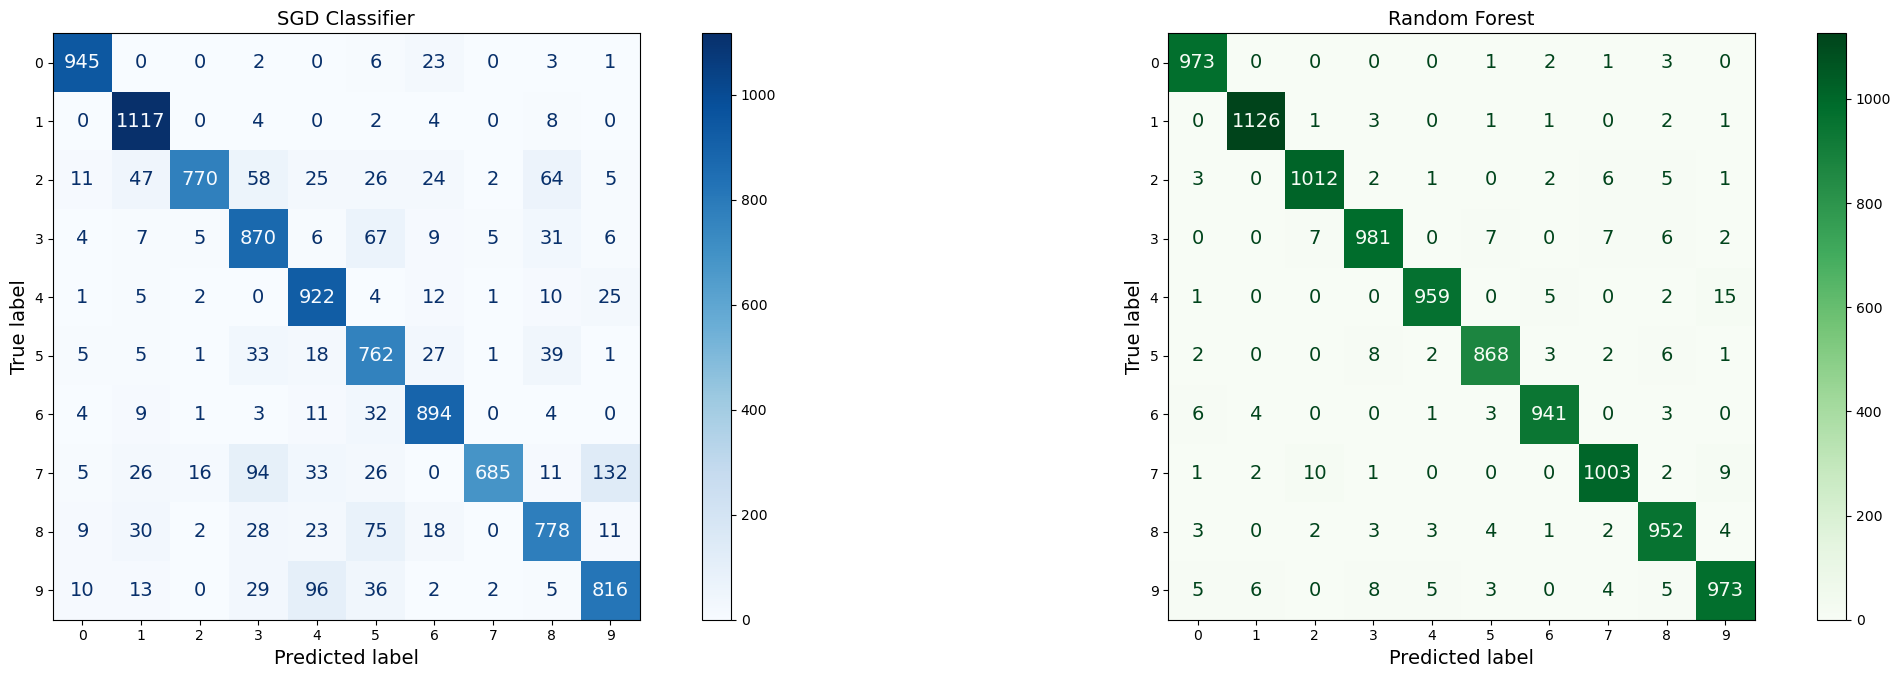

In [20]:
print("\n--- Plotting Confusion Matrices for all classes ---")
fig, axes = plt.subplots(1, 2, figsize=(24, 7))

ConfusionMatrixDisplay.from_estimator(sgd_clf, X_test, y_test, ax=axes[0], cmap="Blues", values_format="d")
axes[0].set_title("SGD Classifier")

ConfusionMatrixDisplay.from_estimator(rf_clf, X_test, y_test, ax=axes[1], cmap="Greens", values_format="d")
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()

## Key findings

Data augmentation was highly effective. It significantly boosted the generalization capability of the Random Forest, allowing it to outperform the linear baseline without requiring new real-world data.

SGD Classifier: As a linear model, it struggled to capture the complex, non-linear pixel relationships of shifted digits, resulting in lower overall accuracy and "blurrier" confusion matrices.

Random Forest: This model achieved the highest results. Its non-linear decision trees, combined with the augmented data, allowed it to robustly distinguish structurally similar digits (like '3' vs '5' or '1' vs '7').